# Enhanced Method 1

This notebook evaluates three leakage-safe residual correction methods for routing-engine ETA:

1. **API + Global Median Residual**
2. **API + Time-bin Median Residual**
3. **API + Smoothed Time-bin Median Residual**

Both methods keep the API ETA (`estimate_time`) as the prior and learn a correction from historical residuals:

```text
residual_secs = actual_eta_secs - api_eta_secs
corrected_eta_secs = api_eta_secs + learned_residual_secs
```

`predict_time` is intentionally not used here because the goal is to calibrate the routing API forecast, not combine with another model output.

## Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "output_log.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/output_log.csv from the current working directory.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "output_log.csv"
ARTIFACT_DIR = PROJECT_ROOT / "residual_modeling" / "artifacts"

DATA_PATH

WindowsPath('D:/vinAI/GSM/Map/ETA-prediction/data/output_log.csv')

## Load and validate data

In [2]:
required_columns = {
    "stationId",
    "destination_stationId",
    "hour",
    "lat",
    "lng",
    "destination_lat",
    "destination_lng",
    "delta_time",
    "estimate_time",
    "timestamp",
}

raw_df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns - set(raw_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_columns = ["delta_time", "estimate_time", "hour", "lat", "lng", "destination_lat", "destination_lng"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_mask = (
    df["timestamp"].isna()
    | df["delta_time"].isna()
    | df["estimate_time"].isna()
    | (df["delta_time"] <= 0)
    | (df["estimate_time"] < 0)
)
if invalid_mask.any():
    print(f"Dropping {int(invalid_mask.sum())} invalid rows.")
    df = df.loc[~invalid_mask].copy()

df = df.sort_values("timestamp").reset_index(drop=True)
df["api_eta_secs"] = df["estimate_time"].astype(float)
df["actual_eta_secs"] = df["delta_time"].astype(float)
df["residual_secs"] = df["actual_eta_secs"] - df["api_eta_secs"]
df["od_pair"] = df["stationId"].astype(str) + "->" + df["destination_stationId"].astype(str)

data_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "timestamp_min": [df["timestamp"].min()],
        "timestamp_max": [df["timestamp"].max()],
        "unique_od_pairs": [df["od_pair"].nunique()],
        "actual_mean_secs": [df["actual_eta_secs"].mean()],
        "api_eta_mean_secs": [df["api_eta_secs"].mean()],
        "residual_median_secs": [df["residual_secs"].median()],
        "residual_mean_secs": [df["residual_secs"].mean()],
    }
)
data_summary

,rows,timestamp_min,timestamp_max,unique_od_pairs,actual_mean_secs,api_eta_mean_secs,residual_median_secs,residual_mean_secs
0,308,2026-01-01 05:23:27,2026-03-30 18:21:39,1,188.479,157.662,15.406,30.817


In [3]:
df[["timestamp", "stationId", "destination_stationId", "hour", "actual_eta_secs", "api_eta_secs", "residual_secs"]].head(10)

,timestamp,stationId,destination_stationId,hour,actual_eta_secs,api_eta_secs,residual_secs
0,2026-01-01 05:23:27,1992,323,5,172.533,158.610,13.923
1,2026-01-01 13:24:44,1992,323,13,125.455,151.610,-26.155
2,2026-01-01 17:23:10,1992,323,17,127.549,182.110,-54.561
3,2026-01-02 17:57:04,1992,323,17,175.900,144.440,31.460
4,2026-01-02 18:06:26,1992,323,18,185.006,144.440,40.566
5,2026-01-03 20:08:45,1992,323,20,134.840,146.610,-11.770
6,2026-01-04 08:41:33,1992,323,8,155.915,133.610,22.305
7,2026-01-04 13:25:58,1992,323,13,154.048,141.110,12.938
8,2026-01-05 07:28:48,1992,323,7,194.748,162.110,32.638
9,2026-01-05 15:10:54,1992,323,15,190.113,145.610,44.503


## Chronological split

The split is time-based: first 70% train, next 15% validation, last 15% test. All residual medians are fit on train only.

In [4]:
def chronological_split(frame: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    if train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio + val_ratio must be < 1.")
    n_rows = len(frame)
    train_end = int(n_rows * train_ratio)
    val_end = int(n_rows * (train_ratio + val_ratio))
    return (
        frame.iloc[:train_end].copy(),
        frame.iloc[train_end:val_end].copy(),
        frame.iloc[val_end:].copy(),
    )


train_df, val_df, test_df = chronological_split(df)

split_summary = pd.DataFrame(
    [
        {"split": name, "rows": len(frame), "timestamp_min": frame["timestamp"].min(), "timestamp_max": frame["timestamp"].max()}
        for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]
    ]
)
split_summary

,split,rows,timestamp_min,timestamp_max
0,train,215,2026-01-01 05:23:27,2026-03-14 08:24:30
1,val,46,2026-03-14 09:06:41,2026-03-23 14:10:14
2,test,47,2026-03-23 15:07:42,2026-03-30 18:21:39


## Method 1: API + Global Median Residual

This method learns one robust scalar correction from train residuals:

```text
global_residual = median(train.actual_eta_secs - train.api_eta_secs)
global_corrected_eta = api_eta_secs + global_residual
```

In [5]:
global_median_residual_secs = float(train_df["residual_secs"].median())
global_mean_residual_secs = float(train_df["residual_secs"].mean())

global_method_summary = pd.DataFrame(
    {
        "method": ["api_plus_global_median_residual"],
        "global_median_residual_secs": [global_median_residual_secs],
        "train_mean_residual_secs": [global_mean_residual_secs],
        "train_rows": [len(train_df)],
    }
)
global_method_summary

,method,global_median_residual_secs,train_mean_residual_secs,train_rows
0,api_plus_global_median_residual,15.795,31.637,215


## Method 2: API + Time-bin Median Residual

Instead of learning residual by every raw hour, we group hours into operational time bins:

- `early_morning`: 4-6h
- `morning_peak`: 7-9h
- `off_peak_day`: 10-14h
- `evening_peak`: 15-18h
- `late_evening`: 19-21h
- `other`: outside these bins

Then fit one median residual per bin on train:

```text
time_bin_residual = median(train.residual_secs | train.time_bin)
time_bin_corrected_eta = api_eta_secs + time_bin_residual[time_bin]
```

If a validation/test row belongs to a bin not observed in train, the model falls back to the global train median residual.

In [6]:
TIME_BIN_ORDER = ["early_morning", "morning_peak", "off_peak_day", "evening_peak", "late_evening", "other"]


def assign_time_bin(hour: float | int) -> str:
    if pd.isna(hour):
        return "other"
    hour = int(hour)
    if 4 <= hour <= 6:
        return "early_morning"
    if 7 <= hour <= 9:
        return "morning_peak"
    if 10 <= hour <= 14:
        return "off_peak_day"
    if 15 <= hour <= 18:
        return "evening_peak"
    if 19 <= hour <= 21:
        return "late_evening"
    return "other"


for split_df in [train_df, val_df, test_df]:
    split_df["time_bin"] = split_df["hour"].map(assign_time_bin)

time_bin_residuals = (
    train_df.groupby("time_bin", observed=True)
    .agg(
        train_rows=("residual_secs", "size"),
        median_residual_secs=("residual_secs", "median"),
        mean_residual_secs=("residual_secs", "mean"),
        p25_residual_secs=("residual_secs", lambda values: float(np.percentile(values, 25))),
        p75_residual_secs=("residual_secs", lambda values: float(np.percentile(values, 75))),
    )
    .reindex(TIME_BIN_ORDER)
)
time_bin_residuals["fallback_used_when_missing"] = time_bin_residuals["median_residual_secs"].isna()
time_bin_residuals["median_residual_secs"] = time_bin_residuals["median_residual_secs"].fillna(global_median_residual_secs)
time_bin_residuals["train_rows"] = time_bin_residuals["train_rows"].fillna(0).astype(int)
time_bin_residuals

,train_rows,median_residual_secs,mean_residual_secs,p25_residual_secs,p75_residual_secs,fallback_used_when_missing
time_bin,,,,,,
early_morning,29,1.709,12.360,-23.916,33.314,False
morning_peak,30,20.922,36.957,-4.836,52.489,False
off_peak_day,35,5.807,13.637,-17.990,25.631,False
evening_peak,116,24.814,42.809,-4.160,62.476,False
late_evening,5,-11.770,-21.659,-44.965,-1.775,False
other,0,15.795,NaN,NaN,NaN,True


In [ ]:
smoothing_search_df.sort_values(["val_mae", "val_p95", "prior_strength"]).round(3)

## Predict

In [7]:
time_bin_residual_map = time_bin_residuals["median_residual_secs"].to_dict()
smoothed_time_bin_residual_map = smoothed_time_bin_residuals["smoothed_residual_secs"].to_dict()

for split_df in [train_df, val_df, test_df]:
    split_df["api_baseline_eta_secs"] = split_df["api_eta_secs"]
    split_df["global_corrected_eta_secs"] = split_df["api_eta_secs"] + global_median_residual_secs
    split_df["time_bin_residual_secs"] = split_df["time_bin"].map(time_bin_residual_map).fillna(global_median_residual_secs)
    split_df["time_bin_corrected_eta_secs"] = split_df["api_eta_secs"] + split_df["time_bin_residual_secs"]
    split_df["smoothed_time_bin_residual_secs"] = split_df["time_bin"].map(smoothed_time_bin_residual_map).fillna(global_median_residual_secs)
    split_df["smoothed_time_bin_corrected_eta_secs"] = split_df["api_eta_secs"] + split_df["smoothed_time_bin_residual_secs"]
    split_df["api_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["api_baseline_eta_secs"]).abs()
    split_df["global_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["global_corrected_eta_secs"]).abs()
    split_df["time_bin_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["time_bin_corrected_eta_secs"]).abs()
    split_df["smoothed_time_bin_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["smoothed_time_bin_corrected_eta_secs"]).abs()

test_df[
    [
        "timestamp",
        "hour",
        "time_bin",
        "actual_eta_secs",
        "api_eta_secs",
        "global_corrected_eta_secs",
        "time_bin_corrected_eta_secs",
        "smoothed_time_bin_corrected_eta_secs",
        "api_abs_error_secs",
        "global_abs_error_secs",
        "time_bin_abs_error_secs",
        "smoothed_time_bin_abs_error_secs",
    ]
].head(12)

,timestamp,hour,time_bin,actual_eta_secs,api_eta_secs,global_corrected_eta_secs,time_bin_corrected_eta_secs,api_abs_error_secs,global_abs_error_secs,time_bin_abs_error_secs
261,2026-03-23 15:07:42,15,evening_peak,136.422,145.610,161.405,170.424,9.188,24.984,34.002
262,2026-03-23 17:13:37,17,evening_peak,122.146,162.610,178.405,187.424,40.464,56.260,65.278
263,2026-03-23 18:06:04,18,evening_peak,191.931,175.610,191.405,200.424,16.321,0.525,8.493
264,2026-03-23 18:11:54,18,evening_peak,264.974,175.610,191.405,200.424,89.364,73.569,64.551
265,2026-03-23 19:00:37,19,late_evening,178.022,190.110,205.905,178.340,12.088,27.883,0.318
266,2026-03-24 04:42:16,4,early_morning,156.960,156.110,171.905,157.819,0.850,14.946,0.859
267,2026-03-24 05:41:49,5,early_morning,188.977,155.610,171.405,157.319,33.367,17.572,31.659
268,2026-03-24 06:35:21,6,early_morning,146.279,127.610,143.405,129.319,18.669,2.874,16.960
269,2026-03-24 07:10:39,7,morning_peak,197.943,146.610,162.405,167.532,51.333,35.538,30.412
270,2026-03-24 10:53:58,10,off_peak_day,139.448,157.110,172.905,162.917,17.662,33.457,23.469


## Evaluation

Metrics are computed on final ETA seconds, not only residual error. Improvements are relative to the raw API ETA within the same split.

In [8]:
def regression_metrics(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "mae": float(np.mean(abs_error)),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "mape": float(np.mean(abs_error / denom) * 100.0),
        "median_absolute_error": float(np.median(abs_error)),
        "p50": float(np.percentile(abs_error, 50)),
        "p90": float(np.percentile(abs_error, 90)),
        "p95": float(np.percentile(abs_error, 95)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
    }


def evaluate_method(split_name: str, frame: pd.DataFrame, method_name: str, prediction_column: str) -> dict[str, float | str | int]:
    api_metrics = regression_metrics(frame["actual_eta_secs"], frame["api_baseline_eta_secs"])
    method_metrics = regression_metrics(frame["actual_eta_secs"], frame[prediction_column])
    return {
        "split": split_name,
        "method": method_name,
        "rows": len(frame),
        "mae": method_metrics["mae"],
        "rmse": method_metrics["rmse"],
        "mape": method_metrics["mape"],
        "p50": method_metrics["p50"],
        "p90": method_metrics["p90"],
        "p95": method_metrics["p95"],
        "r2": method_metrics["r2"],
        "mae_improvement_vs_api_pct": (api_metrics["mae"] - method_metrics["mae"]) / api_metrics["mae"] * 100.0,
        "p95_improvement_vs_api_pct": (api_metrics["p95"] - method_metrics["p95"]) / api_metrics["p95"] * 100.0,
    }


evaluation_rows = []
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_eta", "api_baseline_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_global_median_residual", "global_corrected_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_time_bin_median_residual", "time_bin_corrected_eta_secs"))
    evaluation_rows.append(evaluate_method(split_name, split_df, "api_plus_smoothed_time_bin_median_residual", "smoothed_time_bin_corrected_eta_secs"))

metrics_df = pd.DataFrame(evaluation_rows)
metrics_df.round(3)

,split,method,rows,mae,rmse,mape,p50,p90,p95,r2,mae_improvement_vs_api_pct,p95_improvement_vs_api_pct
0,train,api_eta,215,50.385,79.118,22.950,32.381,108.377,173.988,-0.281,0.000,0.000
1,train,api_plus_global_median_residual,215,47.611,74.228,23.174,32.443,98.622,158.193,-0.127,5.505,9.078
2,train,api_plus_time_bin_median_residual,215,46.295,72.503,22.588,30.808,97.015,150.342,-0.076,8.118,13.591
3,val,api_eta,46,61.401,123.239,27.360,40.425,96.876,119.348,-0.164,0.000,0.000
4,val,api_plus_global_median_residual,46,58.623,119.594,27.895,41.099,83.729,103.552,-0.096,4.524,13.235
5,val,api_plus_time_bin_median_residual,46,58.338,118.508,27.719,39.162,93.232,112.875,-0.077,4.988,5.423
6,test,api_eta,47,37.956,56.887,18.344,23.079,84.593,123.750,0.034,0.000,0.000
7,test,api_plus_global_median_residual,47,37.249,52.804,19.578,30.098,68.797,107.954,0.168,1.862,12.764
8,test,api_plus_time_bin_median_residual,47,37.965,51.794,20.452,32.085,64.841,98.936,0.199,-0.024,20.051


In [9]:
test_metrics = metrics_df.loc[metrics_df["split"].eq("test")].copy()
test_metrics.sort_values("mae").round(3)

,split,method,rows,mae,rmse,mape,p50,p90,p95,r2,mae_improvement_vs_api_pct,p95_improvement_vs_api_pct
7,test,api_plus_global_median_residual,47,37.249,52.804,19.578,30.098,68.797,107.954,0.168,1.862,12.764
6,test,api_eta,47,37.956,56.887,18.344,23.079,84.593,123.750,0.034,0.000,0.000
8,test,api_plus_time_bin_median_residual,47,37.965,51.794,20.452,32.085,64.841,98.936,0.199,-0.024,20.051


## Diagnostics

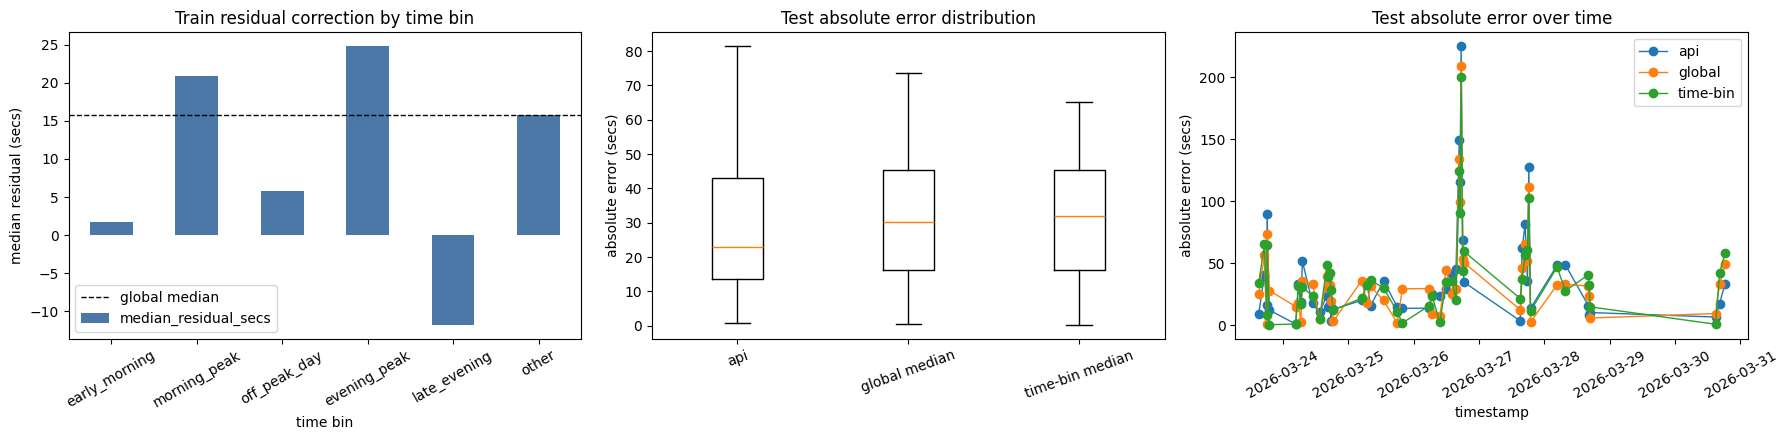

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

time_bin_residuals["median_residual_secs"].plot(kind="bar", ax=axes[0], color="#4c78a8", alpha=0.7, label="raw bin median")
smoothed_time_bin_residuals["smoothed_residual_secs"].plot(ax=axes[0], color="#f58518", marker="o", linewidth=2, label="smoothed")
axes[0].axhline(global_median_residual_secs, color="black", linestyle="--", linewidth=1, label="global median")
axes[0].set_title("Train residual correction by time bin")
axes[0].set_xlabel("time bin")
axes[0].set_ylabel("median residual (secs)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

plot_cols = ["api_abs_error_secs", "global_abs_error_secs", "time_bin_abs_error_secs", "smoothed_time_bin_abs_error_secs"]
plot_labels = ["api", "global median", "time-bin median", "smoothed time-bin"]
axes[1].boxplot([test_df[col].to_numpy() for col in plot_cols], tick_labels=plot_labels, showfliers=False)
axes[1].set_title("Test absolute error distribution")
axes[1].set_ylabel("absolute error (secs)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].plot(test_df["timestamp"], test_df["api_abs_error_secs"], marker="o", linewidth=1, label="api")
axes[2].plot(test_df["timestamp"], test_df["global_abs_error_secs"], marker="o", linewidth=1, label="global")
axes[2].plot(test_df["timestamp"], test_df["time_bin_abs_error_secs"], marker="o", linewidth=1, label="time-bin")
axes[2].plot(test_df["timestamp"], test_df["smoothed_time_bin_abs_error_secs"], marker="o", linewidth=1, label="smoothed")
axes[2].set_title("Test absolute error over time")
axes[2].set_xlabel("timestamp")
axes[2].set_ylabel("absolute error (secs)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend()

plt.tight_layout()

## Save reusable artifacts

In [11]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

all_predictions = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

prediction_columns = [
    "split",
    "timestamp",
    "stationId",
    "destination_stationId",
    "hour",
    "time_bin",
    "api_eta_secs",
    "actual_eta_secs",
    "residual_secs",
    "global_corrected_eta_secs",
    "time_bin_residual_secs",
    "time_bin_corrected_eta_secs",
    "smoothed_time_bin_residual_secs",
    "smoothed_time_bin_corrected_eta_secs",
    "api_abs_error_secs",
    "global_abs_error_secs",
    "time_bin_abs_error_secs",
    "smoothed_time_bin_abs_error_secs",
]

predictions_path = ARTIFACT_DIR / "enhanced_method_1_predictions.csv"
all_predictions[prediction_columns].to_csv(predictions_path, index=False)

time_bin_path = ARTIFACT_DIR / "enhanced_method_1_time_bin_residuals.csv"
time_bin_residuals.reset_index(names="time_bin").to_csv(time_bin_path, index=False)

smoothed_time_bin_path = ARTIFACT_DIR / "enhanced_method_1_smoothed_time_bin_residuals.csv"
smoothed_time_bin_residuals.reset_index(names="time_bin").to_csv(smoothed_time_bin_path, index=False)

smoothing_search_path = ARTIFACT_DIR / "enhanced_method_1_smoothing_search.csv"
smoothing_search_df.to_csv(smoothing_search_path, index=False)

def to_json_records(frame: pd.DataFrame) -> list[dict]:
    return frame.astype(object).where(pd.notna(frame), None).to_dict(orient="records")


time_bin_records = to_json_records(time_bin_residuals.reset_index(names="time_bin"))
smoothed_time_bin_records = to_json_records(smoothed_time_bin_residuals.reset_index(names="time_bin"))

model_card = {
    "notebook": "residual_modeling/enhanced_method_1.ipynb",
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "target": "actual_eta_secs",
    "api_eta_column": "estimate_time",
    "actual_column": "delta_time",
    "split_strategy": "chronological_70_15_15",
    "methods": {
        "api_plus_global_median_residual": {
            "formula": "api_eta_secs + median(train.residual_secs)",
            "global_median_residual_secs": global_median_residual_secs,
            "train_mean_residual_secs": global_mean_residual_secs,
        },
        "api_plus_time_bin_median_residual": {
            "formula": "api_eta_secs + median(train.residual_secs | train.time_bin)",
            "fallback": "global_median_residual_secs for missing/unseen bins",
            "time_bins": {
                "early_morning": "4-6",
                "morning_peak": "7-9",
                "off_peak_day": "10-14",
                "evening_peak": "15-18",
                "late_evening": "19-21",
                "other": "outside configured bins",
            },
            "time_bin_residuals": time_bin_records,
        },
        "api_plus_smoothed_time_bin_median_residual": {
            "formula": "api_eta_secs + shrink(median(train.residual_secs | train.time_bin), global_median_residual_secs)",
            "shrinkage_formula": "n_bin / (n_bin + prior_strength) * bin_median + prior_strength / (n_bin + prior_strength) * global_median",
            "prior_strength_selection": "best validation MAE, tie-broken by validation P95 then smaller prior_strength",
            "prior_strength_grid": SMOOTHING_PRIOR_GRID,
            "best_prior_strength": best_prior_strength,
            "validation_search": to_json_records(smoothing_search_df),
            "smoothed_time_bin_residuals": smoothed_time_bin_records,
        },
    },
    "split_summary": split_summary.assign(
        timestamp_min=split_summary["timestamp_min"].astype(str),
        timestamp_max=split_summary["timestamp_max"].astype(str),
    ).to_dict(orient="records"),
    "metrics": to_json_records(metrics_df),
}

model_card_path = ARTIFACT_DIR / "enhanced_method_1_model_card.json"
model_card_path.write_text(json.dumps(model_card, indent=2, allow_nan=False), encoding="utf-8")

pd.DataFrame(
    {
        "artifact": ["model_card", "predictions", "time_bin_residuals", "smoothed_time_bin_residuals", "smoothing_search"],
        "path": [
            str(model_card_path.relative_to(PROJECT_ROOT)),
            str(predictions_path.relative_to(PROJECT_ROOT)),
            str(time_bin_path.relative_to(PROJECT_ROOT)),
            str(smoothed_time_bin_path.relative_to(PROJECT_ROOT)),
            str(smoothing_search_path.relative_to(PROJECT_ROOT)),
        ],
    }
)

,artifact,path
0,model_card,residual_modeling\artifacts\enhanced_method_1_...
1,predictions,residual_modeling\artifacts\enhanced_method_1_...
2,time_bin_residuals,residual_modeling\artifacts\enhanced_method_1_...
